In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

project_root = Path.cwd().resolve().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [2]:
from reconstruction_io import load_latest_completed_fit3_run
from spectral_reconstruction import reconstruct_all_spectra

from reconstruction_plotting import (
    plot_reconstructed_spectrum,
    plot_spectrum_comparison,
)

In [3]:
results_dir = project_root / "results" / "fit3_run"

run_data = load_latest_completed_fit3_run(results_dir)

print("Loaded run:", run_data["run_dir"])
print("Reconstruction dir:", run_data["reconstruction_dir"])

Loaded run: /Users/marcotamburi/projects/uni_project/svd_project/results/fit3_run/fit3_2026-04-03_10-20-59
Reconstruction dir: /Users/marcotamburi/projects/uni_project/svd_project/results/fit3_run/fit3_2026-04-03_10-20-59/reconstruction


In [4]:
T = run_data["T"]
U_prime = run_data["U_prime"]
x_final = run_data["x_final"]
pack = run_data["pack"]
spectral_matrix = run_data["spectral_matrix"]
wavelengths = run_data["wavelengths"]
reconstruction_dir = run_data["reconstruction_dir"]

In [5]:
reconstruction_result = reconstruct_all_spectra(
    T=T,
    U_prime=U_prime,
    x_full=x_final,
    pack=pack
)

spectra_pred = reconstruction_result["spectra_pred"]
V_pred = reconstruction_result["V_pred"]
M = reconstruction_result["M"]
state_spectra = reconstruction_result["state_spectra"]

s_f shape: (221,)
s_i shape: (221,)
s_u shape: (221,)


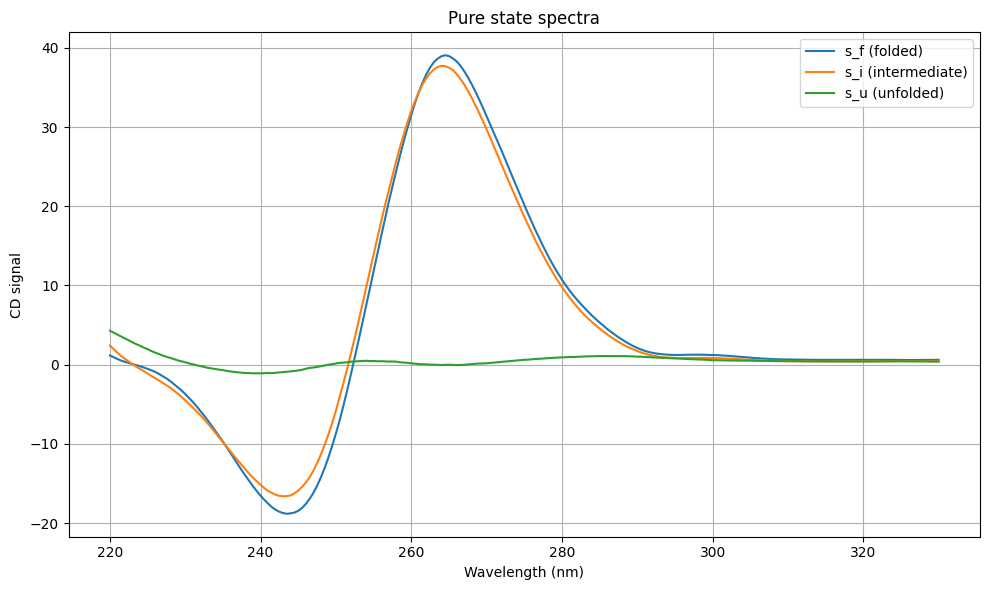

In [6]:
s_f = state_spectra["s_f"]
s_i = state_spectra["s_i"]
s_u = state_spectra["s_u"]

print("s_f shape:", s_f.shape)
print("s_i shape:", s_i.shape)
print("s_u shape:", s_u.shape)

plt.figure(figsize=(10, 6))
plt.plot(wavelengths, state_spectra["s_f"], label="s_f (folded)")
plt.plot(wavelengths, state_spectra["s_i"], label="s_i (intermediate)")
plt.plot(wavelengths, state_spectra["s_u"], label="s_u (unfolded)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("CD signal")
plt.title("Pure state spectra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

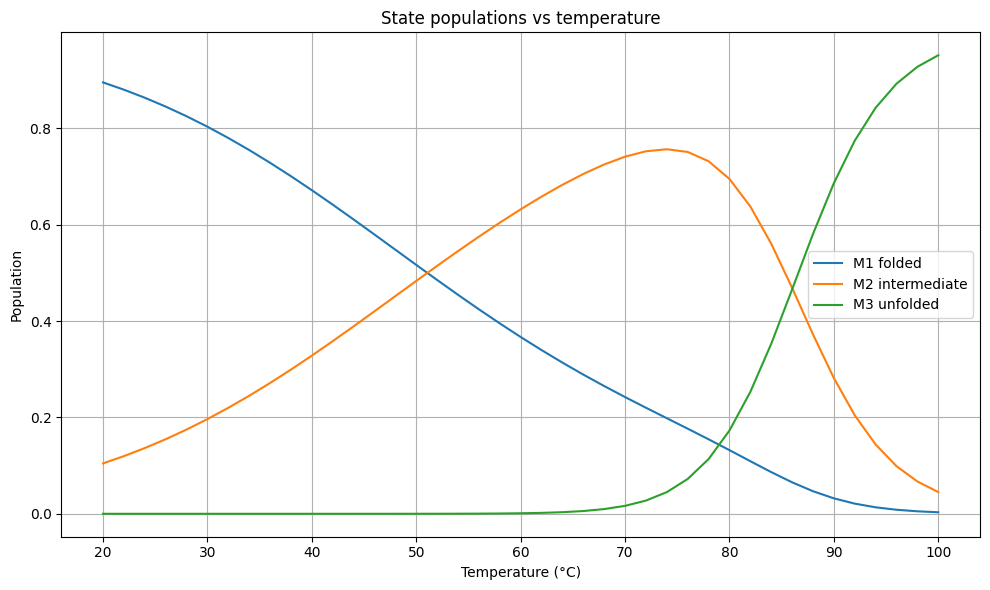

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(T - 273.15, M[0], label="M1 folded")
plt.plot(T - 273.15, M[1], label="M2 intermediate")
plt.plot(T - 273.15, M[2], label="M3 unfolded")
plt.xlabel("Temperature (°C)")
plt.ylabel("Population")
plt.title("State populations vs temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
interact(
    lambda idx: plot_reconstructed_spectrum(
        T=T,
        U_prime=U_prime,
        x_full=x_final,
        pack=pack,
        wavelengths=wavelengths,
        idx=idx,
    ),
    idx=widgets.IntSlider(min=0, max=len(T)-1, step=1)
)

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(idx)>

In [9]:
interact(
    lambda idx: plot_spectrum_comparison(
        spectral_matrix=spectral_matrix,
        spectra_pred=spectra_pred,
        T=T,
        wavelengths=wavelengths,
        idx=idx,
    ),
    idx=widgets.IntSlider(min=0, max=len(T)-1, step=1)
)

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(idx)>